# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

I've selected US E-commerce dataset for this task.
Who: sales executives of a large national convenience store chain
What: Product segmets and categories, driving more revenue and/or generating more profit. If possible broken down by location
How: in this dataset we have almost everything we need for his task: location, product and its segmentation, sales, quantity, and profit

# 3. Homework - work with your own data

In [69]:

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [70]:
df_ecom = pd.read_csv("US  E-commerce records 2020.csv", encoding="latin1")
df_ecom.head()


,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [71]:
df_ecom.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000
mean,5087.107488,56186.515097,221.381418,3.766908,0.156467,28.212340
std,2817.482266,31980.375516,585.257531,2.221776,0.207429,241.864342
min,13.000000,1841.000000,0.444000,1.000000,0.000000,-3839.990400
25%,2655.750000,27978.750000,17.018000,2.000000,0.000000,1.763200
50%,5183.500000,60472.500000,53.810000,3.000000,0.200000,8.296800
75%,7498.250000,90032.000000,205.105700,5.000000,0.200000,28.315125
max,9994.000000,99301.000000,13999.960000,14.000000,0.800000,6719.980800


In [72]:
df_ecom.info()


<class 'pandas.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   str    
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   str    
 3   Ship Mode     3312 non-null   str    
 4   Customer ID   3312 non-null   str    
 5   Segment       3312 non-null   str    
 6   Country       3312 non-null   str    
 7   City          3312 non-null   str    
 8   State         3312 non-null   str    
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   str    
 11  Product ID    3312 non-null   str    
 12  Category      3312 non-null   str    
 13  Sub-Category  3312 non-null   str    
 14  Product Name  3312 non-null   str    
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null   float64
d

In [73]:
# Maksim Hauryli: Order Date was str - I'll change it to datetime
df_ecom["Order Date"] = pd.to_datetime(
    df_ecom["Order Date"],
    errors="coerce"
)

/tmp/ipykernel_8855/1176169577.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_ecom["Order Date"] = pd.to_datetime(


In [74]:
if not df_ecom.duplicated().any():
    print("No duplicates")

No duplicates


-Are there any duplicate values in a given column (when this would be inappropriate?)

Maksim Haurylik: Yes, I assume - but the point is that it is expected here that each column han have duplicated values

In [75]:
numeric_df = df_ecom.select_dtypes(include="number")
numeric_df = numeric_df.drop(columns=["Row ID", "Postal Code"], errors="ignore")
# Not all the columns here are numeric. And I guess, there is no point to find median among the list of postal codes:) -so I'm going to calculate what is needed just for these columns:
mean_vals = numeric_df.mean()
median_vals = numeric_df.median()
mode_vals = numeric_df.mode().iloc[0]

summary_stats = pd.DataFrame({
    "Mean": mean_vals,
    "Median": median_vals,
    "Mode": mode_vals
})

summary_stats


,Mean,Median,Mode
Sales,221.381418,53.8100,12.96
Quantity,3.766908,3.0000,2.00
Discount,0.156467,0.2000,0.00
Profit,28.212340,8.2968,0.00


In [76]:
# Are there any missing or null values?

if not df_ecom.isnull().any().any():
    print("Everything is good")


Everything is good


- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

Maksim Haurylik: nothing like that in this dataset. I've even checked if there are any zero quantities - no, everything is good

In [77]:
# I decided to one-hot encode just these columns:
categorical_cols = [
    "Ship Mode",
    "Segment",
    "State",
    "Region",
    "Category",
    "Sub-Category"
]

df_ecom_encoded = pd.get_dummies(
    df_ecom,
    columns=categorical_cols,
    drop_first=False,
    dtype=int # I thought it would be better to make everything int
)

df_ecom_encoded.head()


,Order Date,Row ID,Order ID,Customer ID,Country,City,Postal Code,Product ID,Product Name,Sales,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,2020-01-01,849,CA-2017-107503,GA-14725,United States,Lorain,44052,FUR-FU-10003878,"Linden 10"" Round Wall Clock, Black",48.896,...,0,0,1,0,0,0,0,0,0,0
1,2020-01-01,4010,CA-2017-144463,SC-20725,United States,Los Angeles,90036,FUR-FU-10001215,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,...,0,0,1,0,0,0,0,0,0,0
2,2020-01-01,6683,CA-2017-154466,DP-13390,United States,Franklin,53132,OFF-BI-10002012,Wilson Jones Easy Flow II Sheet Lifters,3.600,...,0,0,0,0,0,0,0,0,0,0
3,2020-01-01,8070,CA-2017-151750,JM-15250,United States,Huntsville,77340,OFF-ST-10002743,SAFCO Boltless Steel Shelving,454.560,...,0,0,0,0,0,0,0,1,0,0
4,2020-01-01,8071,CA-2017-151750,JM-15250,United States,Huntsville,77340,FUR-FU-10002116,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,...,0,0,1,0,0,0,0,0,0,0


### Conclusions:

- Are the data usable?  If not, find some new data!
--MH: It looks like it is usable

- Do you need to modify or correct the data in some way?
--MH: No, I've only changed the Order Date to datetime

- Is there any class imbalance?  (Categories that have many more items than other categories).
--MH: I wouldn't say so

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

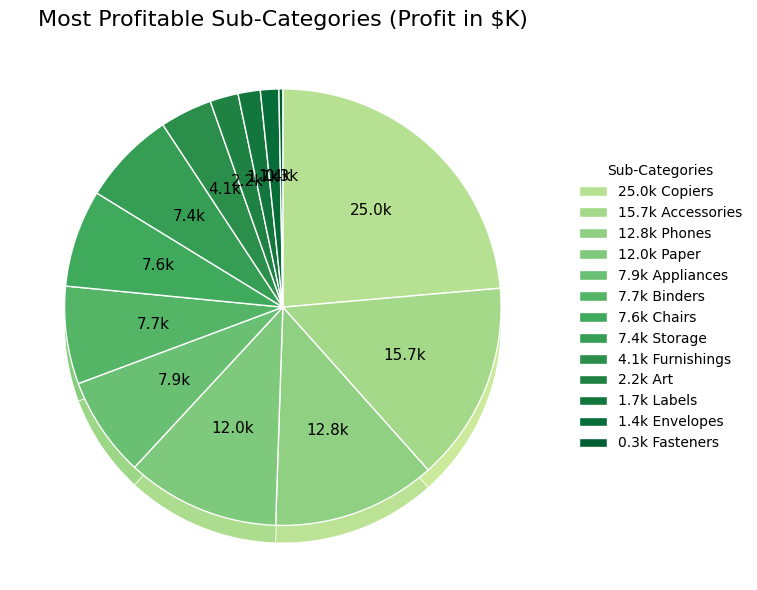

In [78]:
# Maksim: I'm sorry, but the small values look messed up on the chart

import matplotlib.pyplot as plt

profit_by_subcat = (
    df_ecom
    .groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_subcat = profit_by_subcat[profit_by_subcat > 0]   # I keep getting errors for negative values here
profit_k = profit_by_subcat / 1000                          # in thousands of dollars

labels = profit_k.index.tolist()
sizes = profit_k.values
top_colors = plt.cm.YlGn(np.linspace(0.35, 0.9, len(sizes)))
bottom_colors = plt.cm.YlGn(np.linspace(0.25, 0.75, len(sizes)))  # should look darker
legend_labels = [f"{v:.1f}k {name}" for name, v in zip(labels, sizes)]
fig, ax = plt.subplots(figsize=(10, 6))

ax.pie(                                 # Bottom
    sizes,
    startangle=90,
    counterclock=False,
    center=(0, -0.08),                   # shift down to simulate thickness
    radius=1.0,
    colors=bottom_colors,
    wedgeprops=dict(edgecolor="white", linewidth=0.5),
)

wedges, _, _ = ax.pie(                  # Top
    sizes,
    startangle=90,
    counterclock=False,
    center=(0, 0),
    radius=1.0,
    autopct=lambda p: f"{p * sizes.sum() / 100:.1f}k",  # show values in thousands on slices
    colors=top_colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(color="black", fontsize=11),
)

ax.set_title("Most Profitable Sub-Categories (Profit in $K)", fontsize=16)

ax.legend(
    wedges,
    legend_labels,
    title="Sub-Categories",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

ax.set_aspect("equal")
plt.tight_layout()
plt.show()
